In [18]:
# Import dependencies

import os
import wandb
import wandb_workspaces.workspaces as ws
import wandb_workspaces.reports.v2 as wr # We use the Reports API for adding panels

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
WANDB_API_KEY = "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"
ENTITY = "kirill456z"
PROJECT = "physics4llm"

if WANDB_API_KEY:
    os.environ["WANDB_API_KEY"] = WANDB_API_KEY
if ENTITY:
    os.environ["WANDB_ENTITY"] = ENTITY

In [20]:
#import wandb_workspaces.reports.v2 as wr

#report = wr.Report(
     #entity=ENTITY,
     #project=PROJECT,
     #title="22.03",
     #description="A descriptive description.",
#)

#report.save()

In [21]:
report = wr.Report.from_url("https://wandb.ai/kirill456z/physics4llm/reports/22-03--VmlldzoxNjI3ODI3MA")

report.width = 'fluid'

[to_matplotlib] Loaded 3 runs


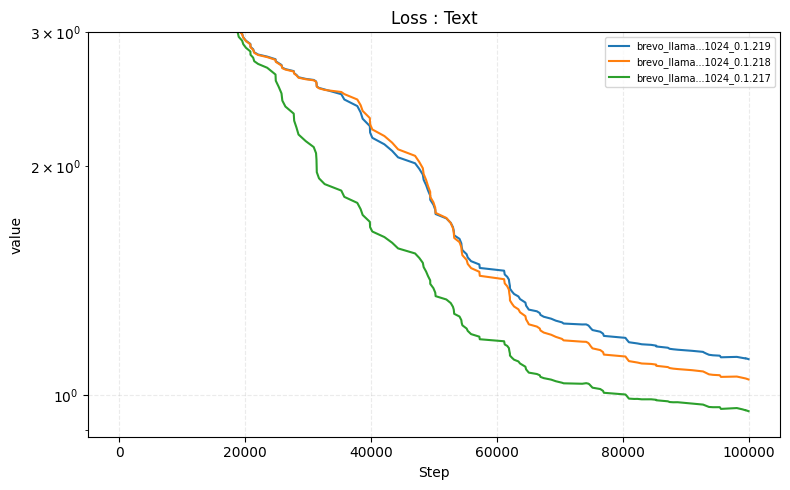

Saved: /Users/kirillzemlanskij/Workspace/PhysicsLM4/reports/plots/march22_brevo_task_losses.png


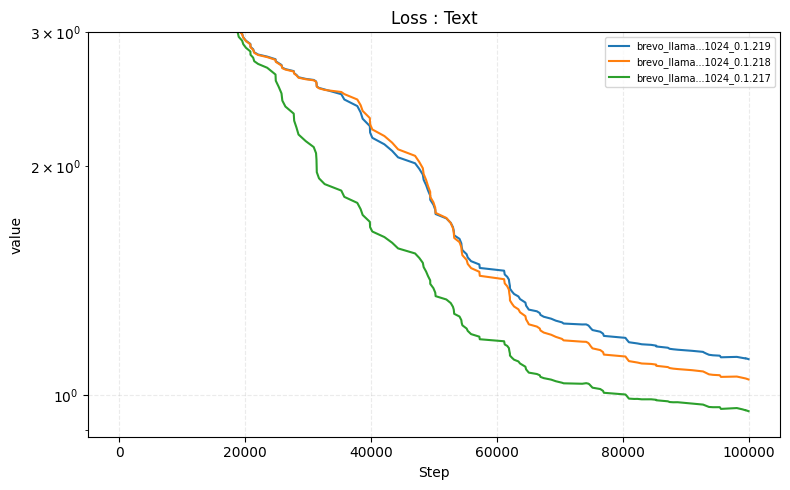

In [22]:
from plots import canon_weight_fixed_layer, speed_cur_iter_time
from plots import loss_lineplot, to_matplotlib
from runsets import RunsetsFactory

runsets_factory = RunsetsFactory(ENTITY, PROJECT)
FAST_PLOT_KWARGS = dict(api_timeout=90, max_points_per_series=150, use_scan_fallback=False)


brevo_runs = [
    "brevo_llama_110_nodes_single_bs_256_seq_len_1024_0.1.219",
    "brevo_llama_110_nodes_single_bs_256_seq_len_1024_0.1.218",
    "brevo_llama_110_nodes_single_bs_256_seq_len_1024_0.1.217"
]



brevo_runs = [runsets_factory.filter_by_run_names(brevo_runs)]

loss_plots = [loss_lineplot(y_max=3)]
loss_fig, loss_path = to_matplotlib(
    loss_plots,
    brevo_runs,
    num_subplots_h=1,
    num_subplots_w=1,
    h=5,
    w=8,
    output_name="march22_brevo_task_losses",
    **FAST_PLOT_KWARGS,
)
print(f"Saved: {loss_path}")

report.blocks = [
    wr.H2("Training on brevo task"),
    wr.P("Still devergent losses"),
    wr.PanelGrid(
        runsets = brevo_runs,
        panels = loss_plots,
        hide_run_sets = True
    ),
]

In [23]:
report.save();

wandb: Saved report to: https://wandb.ai/kirill456z/physics4llm/reports/22.03--VmlldzoxNjI3ODI3MA==
